# EDL-CMSO on VeReMi NextGen — 16-class V2X misbehaviour detection

Rebuild of **"A Secure and Efficient Deep Learning-Based Intrusion Detection Framework
for the Internet of Vehicles"** — Khan, Tejani, AlGhamdi, Alasmari, Sharma & Sharma,
*Scientific Reports* 2025, DOI [`10.1038/s41598-025-94445-9`](https://doi.org/10.1038/s41598-025-94445-9).

**Method (stages 3–5 of the paper).** Each row of 66 `f_*` V2X features is decomposed by a
Haar DWT into approximation and detail bands (Eq. 19), cut into patches and linearly
projected with positional encoding (Eq. 20–21), passed through a Vision Transformer
(Eq. 22–25), then through a Graph Attention Network whose adjacency is *built from* the
attention coefficients over the patch nodes (Eq. 26–27). The three representations are
fused by concatenation (Eq. 28). A CMSO metaheuristic — the exploration phase of the
Crayfish Optimization Algorithm fused with the upbringing phase of the Mother Optimization
Algorithm (Eq. 29–37) — selects the input feature subset. Classification is by **DAGSNet**:
DenseNet, GoogleNet, AlexNet and SqueezeNet branches run in parallel, are concatenated
(Eq. 47) and fed to a fully connected softmax head (Eq. 48, 50).

**Not rebuilt, by the user's instruction:** the IoVCipherGuard crypto front end
(HE / SMPC / AES-256, §4.3–4.6), the preprocessing stage (§4.7 — the dataset already ships
imputed and standardised), and AFPHA federated aggregation (§4.6 — this build is
**centralized**, one model).

---

## Paper vs. this notebook

| # | Paper | This notebook | Why | Kind |
|---|---|---|---|---|
| 1 | CIC-IDS 2017 / CAN / CICIoV2024 | VeReMi NextGen, 16 classes | the user's dataset | forced |
| 2 | binary normal/anomaly reporting | 16-class softmax, `C=16` | our label taxonomy; Eq. (50) permits it | forced |
| 3 | HE + SMPC + AES-256 | omitted | user instruction; affects no reported metric | user |
| 4 | median imputation (§4.7) | omitted — dataset pre-imputed with constant `0.0` *before* the split | a constant fill needs no statistic, so it cannot leak | user / forced |
| 5 | Z-score over the whole set | `train/` already standardised; `scaler.json` (train-only, `ddof=0`) applied to `test/` at load | **never** fit a statistic on test | user / forced |
| 6 | AFPHA federated aggregation | omitted — one centralized model | user decision | user |
| 7 | batch size 64 | **4096 global** (2048/GPU × 2 T4) | user set it | user |
| 8 | 100 epochs | **50 rounds × 1 epoch** over all 43,045,415 train rows | user set it | user |
| 9 | 1× RTX 3090 | 2× T4 DDP, fp16 AMP, `NCCL_P2P_DISABLE=1` | Kaggle hardware; Turing has no bf16/TF32 | hardware |
| 10 | LR 1e-3 "with adaptive decay", schedule unstated | 1e-3, cosine over 50 rounds, 1 warmup round | paper does not state the schedule | judgement |
| 11 | "Optimizer: CMSO" (Table 1) vs "Adam" (§4.9.2) | **Adam** trains weights; **CMSO** selects features | the paper never reconciles the two | judgement |
| 12 | DWT family/level unstated | Haar (`db1`), level 1, fixed non-learnable stride-2 conv | smallest choice satisfying Eq. (19); stays on-GPU | judgement |
| 13 | `p×p` patches over 2-D input | 66 feats → DWT → 66 coeffs → **11 patches of length 6** (66 = 11×6 exactly, no padding). CMSO subsets are floored at 12 features so k ≥ 2 | the input is a flat tabular row; k=1 makes the GAT softmax constant and starves `a_src`/`a_dst` of gradient, hanging DDP | judgement |
| 14 | ViT depth/heads/`d` unstated | `d=128`, 2 layers, 4 heads, FFN ×2, dropout 0.1, pre-norm | must be small: 10,509 steps/round × 50 | judgement |
| 15 | GAT neighbourhood `N(i)` unstated | fully connected over the k patch nodes, 1 layer, 4 heads, LeakyReLU 0.2 | Eq. (26)'s all-pairs numerator implies it | judgement |
| 16 | Eq. (28) concatenates three tensors of different rank | concatenated on the **channel** axis per token → `F ∈ R^{k×384}` | Eq. (28) as printed does not type-check | judgement |
| 17 | backbone depths / 1-D vs 2-D unstated | four **1-D** backbones over `F`, each with a 1×1 stem to 96 ch: DenseNet 3 dense layers (growth 32), GoogleNet 2 inception modules, AlexNet 3 conv+pool, SqueezeNet 3 fire modules; global-avg-pooled then concatenated | tabular rows have no 2-D structure | judgement |
| 18 | CMSO applied *after* feature extraction | CMSO applied to the **66 input features** (binary mask), once, before the 50 rounds | §4.8's features come from a *learned* ViT/GAT that does not exist yet — the paper's ordering is circular | judgement |
| 19 | CMSO `N`,`T`,`C₁`,`μ`,`σ`, mutation, fitness all unstated | `N=20`, `T=50`, `C₁=0.2`, `μ=25`, `σ=3`, mutation 0.05; fitness = macro-F1 of a surrogate MLP on a train-only subsample − `0.01·|S|/66` | none are given; the size penalty encodes "minimizing redundancy" | judgement |
| 20 | Eq. (31)–(35) continuous, selection binary | sigmoid transfer + threshold 0.5 | no binarisation rule given | judgement |
| 21 | 10 binary metrics (Eq. 51–59) | the user's **10 multi-class metrics**: accuracy, P/R/F1 × {macro, micro, weighted} | the user set the metric set; specificity/NPV/MCC/FPR/FNR need a TN that 16 classes do not define without an averaging convention | user |
| 22 | pruning / quantization proposed | not applied | the paper applies them to no reported number either | judgement |
| 23 | Table 3 contrasts with/without feature selection | **one scenario: with CMSO feature selection** | user decision; the budget buys one 50-round run | user |
| 24 | — | `y_prob` saved only for the best and final round; `y_pred` saved every round | 50 × 10.7 M × 16 floats would exceed Kaggle's 20 GB output cap | hardware |

> **⚠ Leakage disclosure — read before quoting any per-class number.**
> **100.00%** of `trafficCongestionSybil` rows sit in a flow where *every* row is a
> first-in-session row (next highest class: `feignedBraking` 0.20%; `dosAttack` 0.00%),
> so the 16 `session` features are very close to a label for that class. **No ablation is
> run in this build** (user decision), therefore a near-perfect Sybil F1 below is
> substantially attributable to the `session` feature group, **not** to DAGSNet detecting
> Sybil behaviour, and this build cannot quantify the split. Also state, per the dataset's
> own reporting requirements: the split is by **time**, not by vehicle; benign comes from
> an attack-free stream, which makes the `rate` group unusually strong; 3,338,358 ambiguous
> rows were dropped upstream; `timeDelayAttack` is the hardest class; imbalance is 41:1;
> and 88% of test flows are one message long — almost all Sybil — kept as-is, since
> DAGSNet is a per-row classifier that never assembles a flow.

In [1]:
# ── Cell 2 · environment probe ───────────────────────────────────────────────
import os, sys, math, json, time, glob, shutil, platform
import numpy as np, torch

NB_T0 = time.time()          # session wall-clock origin; the round budget counts from here

print("python", platform.python_version(), "| torch", torch.__version__, "| cuda", torch.version.cuda)
n = torch.cuda.device_count(); print("GPUs:", n)
for i in range(n):
    p = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i} {p.name} {p.total_memory/2**30:.1f} GB sm_{p.major}{p.minor}")
print("cpu count:", os.cpu_count())
print("RAM GB:", round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 2**30, 1))
for d in ("/kaggle/working", "/kaggle/temp"):
    os.makedirs(d, exist_ok=True)
    print(f"free on {d}:", round(shutil.disk_usage(d).free / 2**30, 1), "GB")

assert n == 2, f"Expected 2x T4 — got {n}. Set Accelerator to 'GPU T4 x2' and restart."
assert torch.cuda.get_device_properties(0).major == 7, \
    "Expected Turing (sm75). fp16 AMP settings below assume no bf16 and no TF32."

# proj package: %%writefile keeps the code visible in the notebook AND importable by
# the processes mp.spawn creates — functions defined in bare cells are not.
import pathlib
PKG = pathlib.Path("/kaggle/working/proj"); PKG.mkdir(parents=True, exist_ok=True)
(PKG / "__init__.py").touch()
sys.path.insert(0, "/kaggle/working")
print("proj package ready")

python 3.12.13 | torch 2.10.0+cu128 | cuda 12.8
GPUs: 2
  cuda:0 Tesla T4 14.6 GB sm_75
  cuda:1 Tesla T4 14.6 GB sm_75
cpu count: 4
RAM GB: 31.3
free on /kaggle/working: 19.5 GB
free on /kaggle/temp: 1026.8 GB
proj package ready


In [2]:
# ── Cell 3 · CFG — the single knob cell ──────────────────────────────────────
from dataclasses import dataclass, asdict, field

@dataclass
class _CFG:
    run_name: str = "edl_cmso_r50_b4096"

    # ---- knobs set by the user ------------------------------------------------
    rounds: int           = 50      # 50 rounds; checkpoints produced = 50
    epochs_per_round: int = 1       # 1 epoch per round  -> 50 epochs total
    batch_per_gpu: int    = 2048    # PER GPU. global = batch_per_gpu * 2 * grad_accum = 4096
    grad_accum: int       = 1
    # ---- paper, Table 1 -------------------------------------------------------
    lr: float             = 1e-3    # "0.001 with adaptive decay"
    weight_decay: float   = 1e-4
    warmup_rounds: int    = 1       # cosine decay after; the paper's schedule is unstated
    # ---------------------------------------------------------------------------

    # architecture (every value here fills a gap the paper leaves unstated)
    patch_len: int    = 6           # deviation 13
    d_model: int      = 128         # deviation 14
    vit_layers: int   = 2
    vit_heads: int    = 4
    vit_mlp_ratio: int= 2
    gat_heads: int    = 4           # deviation 15
    gat_slope: float  = 0.2
    dropout: float    = 0.1
    stem_ch: int      = 96          # deviation 17: 1x1 stem before each backbone
    dense_growth: int = 32
    dense_layers: int = 3
    incep_modules: int= 2
    fire_modules: int = 3

    # CMSO (deviation 19-20) — every one of these is unstated in the paper
    cmso_enabled: bool     = True   # deviation 23: the one scenario we run
    cmso_pop: int          = 20     # N
    cmso_iters: int        = 50     # T
    cmso_C1: float         = 0.2
    cmso_mu: float         = 25.0
    cmso_sigma: float      = 3.0
    cmso_mutation: float   = 0.05
    cmso_size_penalty: float = 0.01 # fitness = macroF1 - penalty * |S|/dim
    cmso_fit_rows: int     = 2_000_000   # train-only subsample for the surrogate
    cmso_val_rows: int     = 300_000     # train-only holdout; NEVER the test set
    cmso_surrogate_steps: int = 400
    cmso_surrogate_batch: int = 8192

    # runtime
    # Kaggle hard-kills a batch session at 12 h. Stop cleanly before that so the final
    # cells run and the output is committed normally, then resume next session.
    max_hours: float  = 11.0
    nccl_timeout_min: int = 60      # rank 1 waits at the barrier for rank 0's full-test eval
    world_size: int   = 2
    amp: bool         = True        # fp16 — T4 has no bf16
    clip: float       = 1.0
    eval_batch: int   = 16384       # test lives on the GPU, so this is loop overhead only
    seed: int         = 42
    resume: bool      = True
    num_classes: int  = -1          # filled from meta.json
    n_features: int   = -1          # filled from meta.json
    save_prob_every: int = 0        # 0 = only best + final round (deviation 24)

CFG = _CFG()
GLOBAL_BATCH = CFG.batch_per_gpu * CFG.world_size * CFG.grad_accum
print(f"global batch = {CFG.batch_per_gpu} x {CFG.world_size} x {CFG.grad_accum} = {GLOBAL_BATCH}")
print(f"rounds = {CFG.rounds}  x  epochs_per_round = {CFG.epochs_per_round}"
      f"  ->  {CFG.rounds * CFG.epochs_per_round} passes over train")
print(f"session budget = {CFG.max_hours} h wall clock (Kaggle kills at 12 h)")

global batch = 2048 x 2 x 1 = 4096
rounds = 50  x  epochs_per_round = 1  ->  50 passes over train
session budget = 11.0 h wall clock (Kaggle kills at 12 h)


In [3]:
# ── Cell 4 · paths, run scaffold, resume probe ───────────────────────────────
from pathlib import Path

# Kaggle wipes /kaggle/working on a NEW session but commits it as output; /kaggle/temp is
# never committed. Big derived arrays go to temp (rebuilt in ~minutes); anything that must
# survive the session goes to working.
CACHE = Path("/kaggle/temp/veremi_cache"); CACHE.mkdir(parents=True, exist_ok=True)
RUNS  = Path("/kaggle/working/runs");      RUNS.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUNS / CFG.run_name
for s in ("checkpoints", "metrics", "preds", "confusion", "reports", "logs"):
    (RUN_DIR / s).mkdir(parents=True, exist_ok=True)

# Say what is actually mounted BEFORE asserting: a bare "not attached" tells you nothing
# about whether the source is missing or merely nested somewhere unexpected.
print("-- /kaggle/input --")
if os.path.isdir("/kaggle/input"):
    for root, dirs, files in os.walk("/kaggle/input"):
        depth = root.count("/") - 2
        if depth > 3: dirs[:] = []; continue
        print("  " * depth + Path(root).name + "/" +
              (f"   [{len(files)} files]" if files else ""))
else:
    print("  /kaggle/input does not exist — no data source is attached at all")

# Recursive: this dataset nests the split dirs one level down (upload/train, upload/test),
# and a re-upload could nest them differently again. Match any depth, and require that the
# directory actually holds parquet so an empty namesake cannot be picked.
cands = sorted(p for p in glob.glob("/kaggle/input/**/train", recursive=True)
               if os.path.isdir(p) and glob.glob(os.path.join(p, "*.parquet")))
assert cands, ("Dataset not attached, or attached without parquet under a 'train/' dir. "
               "Add 'odixe0502/veremi-nextgen2026-centralized' via + Add Input, then re-run. "
               "The tree printed above is what the session actually sees.")
DATA = Path(cands[0]).parent
print("\ndataset root:", DATA)
for f in sorted(os.listdir(DATA)):
    p = DATA / f
    extra = f" ({len(os.listdir(p))} files)" if p.is_dir() else f" ({p.stat().st_size/2**20:.1f} MiB)"
    print("  ", f, extra)

# ---- resume probe: say plainly what is already done before anything runs ----
def probe():
    last = RUN_DIR / "checkpoints" / "last.pt"
    imported = sorted(glob.glob(f"/kaggle/input/*/runs/{CFG.run_name}/checkpoints/last.pt")) \
             + sorted(glob.glob("/kaggle/input/*/checkpoints/last.pt"))
    hist = RUN_DIR / "metrics" / "history.csv"
    print("\n-- resume probe --")
    print("  local last.pt      :", "yes" if last.exists() else "no")
    print("  attached last.pt   :", imported[0] if imported else "none")
    print("  local history.csv  :", f"{sum(1 for _ in open(hist))-1} rows" if hist.exists() else "absent")
    mask = RUN_DIR / "feature_mask.json"
    print("  CMSO mask          :", "cached" if mask.exists() else "not yet run")
probe()

-- /kaggle/input --
input/
  datasets/
    odixe0502/
      veremi-nextgen2026-centralized/

dataset root: /kaggle/input/datasets/odixe0502/veremi-nextgen2026-centralized/upload
   README.md  (0.0 MiB)
   feature_schema.json  (0.0 MiB)
   label_mapping.json  (0.0 MiB)
   load_test.py  (0.0 MiB)
   manifest.json  (0.1 MiB)
   scaler.json  (0.0 MiB)
   statistics.json  (0.0 MiB)
   statistics.md  (0.0 MiB)
   test  (8 files)
   train  (30 files)

-- resume probe --
  local last.pt      : no
  attached last.pt   : none
  local history.csv  : absent
  CMSO mask          : not yet run


## Dataset — VeReMi NextGen, 16-class centralized

Derived from Zenodo record `19665762` (DOI `10.5281/zenodo.19665762`). One row is one
received CAM message, seen from the receiving vehicle's side.

| split | files | rows | size | feature state |
|---|---:|---:|---:|---|
| `train/` | 15 | 43,045,415 | 7.3 GiB | imputed **and standardised** — use as is |
| `test/` | 4 | 10,761,343 | 1.7 GiB | imputed, **not standardised** |

**A column is a model feature if and only if its name starts with `f_`** — 66 of them,
float32, grouped as `raw` 15, `position` 4, `geometry` 20, `session` 16, `rate` 5,
`profile` 6. Everything else is leakage and is dropped: 9 identifiers (`receiver_id`,
`sender_id`, `sender_alias`, `message_id`, `rcv_time_ns`, `send_time_ns`, `orig_split`,
`source_run`, `t_rel_s`), 9 raw-context columns, plus `attack_type` and `scenario`, which
are partition columns materialised as real columns and would hand the model the answer.

**The two preprocessing steps and why the notebook skips one and applies the other.**
Imputation came *first*, before the split: every non-finite cell was filled with a constant
`0.0` while the features were one continuous stream. A constant fill needs no statistic, so
its position in the order cannot leak test into train. The 13 `zero_imputed_features` are
session deltas with no value on a session's first message — `f_first_in_session` is `1` on
exactly those rows, so the imputation stays visible to the model rather than hidden.
Standardisation came *second* and **on train only**: `mean` and `std_used` in `scaler.json`
were fitted on the 43,045,415 train rows with population variance (`ddof=0`). So `train/`
is consumed untouched, and `test/` gets that frozen transform applied at load. The cell
below asserts we never do it the other way round.

The split is by **simulation time**, with a separate cut point per (class × scenario) —
64 cut points, `rcv_time_ns < t*` to train. Nothing is split randomly, so no message leaks
from a session's future into its past. The test split is given; we do not create one.

In [4]:
# ── Cell 6 · ONE pass over parquet: audit and materialise together ───────────
import pyarrow.parquet as pq
import pandas as pd

TRAIN_DIR, TEST_DIR = DATA / "train", DATA / "test"
train_files = sorted(glob.glob(str(TRAIN_DIR / "*.parquet")))
test_files  = sorted(glob.glob(str(TEST_DIR  / "*.parquet")))
print(f"train shards: {len(train_files)}   test shards: {len(test_files)}")

schema = pq.ParquetFile(train_files[0]).schema_arrow
all_cols     = list(schema.names)
FEATURES     = [c for c in all_cols if c.startswith("f_")]     # the ONLY rule that matters
NON_FEATURES = [c for c in all_cols if not c.startswith("f_")]
print(f"\ncolumns: {len(all_cols)}   features (f_*): {len(FEATURES)}   dropped: {len(NON_FEATURES)}")
print("dropped as identifiers / labels / raw context / partition keys:")
print("  ", NON_FEATURES)

# sidecar json shipped with the dataset
def load_json(name):
    p = DATA / name
    return json.load(open(p)) if p.exists() else None
fschema, scaler_j, labmap, manifest = (load_json(f) for f in
    ("feature_schema.json", "scaler.json", "label_mapping.json", "manifest.json"))

FEATURE_GROUPS = {}
if fschema:
    declared = fschema["feature_columns"]
    assert declared == FEATURES, "feature_schema.json disagrees with the f_* rule — stop and inspect."
    print("\nfeature_schema.json agrees with the f_* rule.")
    FEATURE_GROUPS = fschema.get("groups") or fschema.get("feature_groups") or {}
    if FEATURE_GROUPS:
        print("groups:", {k: len(v) for k, v in FEATURE_GROUPS.items()})
    if "zero_imputed_features" in fschema:
        print(f"zero-imputed session features: {len(fschema['zero_imputed_features'])}")

# Frozen class axis — the index order must be identical across rounds AND sessions.
# This dataset's label_mapping.json carries three mutually redundant views:
#   label_to_class {"0": "benign", ...}   classes [ordered]   class_to_label {name: idx}
# Read the authoritative one and assert the other two agree; a disagreement means the
# class axis is not actually frozen, which silently corrupts every per-class number.
if labmap and "label_to_class" in labmap:
    inv = {int(k): v for k, v in labmap["label_to_class"].items()}
    CLASS_NAMES = [inv[i] for i in range(len(inv))]
    if "classes" in labmap:
        assert list(labmap["classes"]) == CLASS_NAMES, \
            "label_mapping.json: classes[] disagrees with label_to_class"
    if "class_to_label" in labmap:
        assert labmap["class_to_label"] == {n: i for i, n in enumerate(CLASS_NAMES)}, \
            "label_mapping.json: class_to_label is not the inverse of label_to_class"
    print("label_mapping.json: all three views agree on the class axis.")
elif labmap and all(str(k).isdigit() for k in labmap):
    inv = {int(k): v for k, v in labmap.items()}
    CLASS_NAMES = [inv[i] for i in range(len(inv))]
else:
    CLASS_NAMES = [f"class_{i}" for i in range(16)]
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n{NUM_CLASSES} classes:"); [print(f"  {i:2d}  {n}") for i, n in enumerate(CLASS_NAMES)]

# scaler is fitted on TRAIN ONLY, ddof=0, and is applied to TEST ONLY
assert scaler_j is not None, "scaler.json missing — test cannot be standardised correctly."
SC = scaler_j["features"]
SC_MEAN = np.array([SC[c]["mean"]     for c in FEATURES], dtype=np.float32)
SC_STD  = np.array([SC[c]["std_used"] for c in FEATURES], dtype=np.float32)
assert (SC_STD > 0).all(), "a zero std_used would divide by zero"
print("\nscaler.json loaded: fitted on train, applied to test only (deviation 5).")

# ── the single pass ──────────────────────────────────────────────────────────
# Row counts come from the parquet FOOTERS — metadata only, nothing decoded — so the
# memmaps can be allocated before the one and only decode pass. The earlier version
# streamed every row group twice (once to audit, once to materialise); /kaggle/temp is
# wiped on every new session, so that second decode was paid again every session.
XTR = CACHE / "train_X.f16.npy"; YTR = CACHE / "train_y.i8.npy"
XTE = CACHE / "test_X.f16.npy";  YTE = CACHE / "test_y.i8.npy"
META  = CACHE / "meta.json"
AUDIT = CACHE / "audit.json"

def footer_rows(files):
    return sum(pq.ParquetFile(f).metadata.num_rows for f in files)

t_meta = time.time()
N_TRAIN, N_TEST = footer_rows(train_files), footer_rows(test_files)
print(f"\nrow counts from parquet footers in {time.time()-t_meta:.1f}s: "
      f"train {N_TRAIN:,}   test {N_TEST:,}")

def report(name, a):
    counts = np.asarray(a["counts"], dtype=np.int64); rows = a["rows"]
    print(f"\n{'='*72}\n{name}: {rows:,} rows x {len(FEATURES)} features\n{'='*72}")
    df = pd.DataFrame({"class": CLASS_NAMES, "count": counts,
                       "pct": (100 * counts / rows).round(4)})
    print(df.to_string(index=False))
    nz = counts[counts > 0]
    print(f"imbalance ratio: {counts.max() / max(nz.min(), 1):,.1f} : 1")
    print(f"empty classes  : {[CLASS_NAMES[i] for i in np.where(counts == 0)[0]] or 'none'}")
    print(f"NaN cells: {a['nan']}   Inf cells: {a['inf']}")
    assert a["nan"] == 0 and a["inf"] == 0, "dataset promises no NaN/Inf — it has some. Stop."
    print(f"feature min {a['min']:.3f}  max {a['max']:.3f}  mean(|mean|) {a['absmean']:.4f}")

def scan(files, n_rows, xp, yp, name, standardise):
    """Decode each row group ONCE: accumulate the audit and write the fp16 memmap
    from the same decoded block."""
    cache = json.loads(AUDIT.read_text()) if AUDIT.exists() else {}
    if xp.exists() and yp.exists() and xp.stem in cache:
        a = cache[xp.stem]
        print(f"\n{name}: cached from this session — parquet not re-read")
        report(name, a)
        return a["rows"], np.asarray(a["counts"], dtype=np.int64)

    X = np.lib.format.open_memmap(xp, mode="w+", dtype=np.float16, shape=(n_rows, len(FEATURES)))
    Y = np.lib.format.open_memmap(yp, mode="w+", dtype=np.int8,   shape=(n_rows,))
    counts = np.zeros(NUM_CLASSES, np.int64)
    nan_hits = inf_hits = 0
    mn = np.full(len(FEATURES),  np.inf, np.float64)
    mx = np.full(len(FEATURES), -np.inf, np.float64)
    ssum = np.zeros(len(FEATURES), np.float64)
    i = 0; t0 = time.time()
    for fp in files:
        for b in pq.ParquetFile(fp).iter_batches(batch_size=1_000_000,
                                                 columns=FEATURES + ["label"]):
            m = len(b["label"])
            A = np.column_stack([np.asarray(b[c], dtype=np.float32) for c in FEATURES])
            if standardise:                      # test only — frozen train statistics
                A = (A - SC_MEAN) / SC_STD
            yb = np.asarray(b["label"], dtype=np.int64)
            # --- audit, on the float32 block, before the fp16 cast ---
            counts += np.bincount(yb, minlength=NUM_CLASSES)
            nan_hits += int(np.isnan(A).sum()); inf_hits += int(np.isinf(A).sum())
            mn = np.minimum(mn, A.min(0)); mx = np.maximum(mx, A.max(0))
            ssum += A.sum(0, dtype=np.float64)
            # --- materialise, same block ---
            X[i:i+m] = A.astype(np.float16); Y[i:i+m] = yb.astype(np.int8)
            i += m
        print(f"    {Path(fp).name}: {i:,}/{n_rows:,}  ({time.time()-t0:.0f}s)", flush=True)
    assert i == n_rows, f"row count mismatch {i} != {n_rows}"
    X.flush(); Y.flush()
    a = {"rows": int(i), "counts": counts.tolist(), "nan": nan_hits, "inf": inf_hits,
         "min": float(mn.min()), "max": float(mx.max()),
         "absmean": float(np.abs(ssum / i).mean()), "seconds": round(time.time() - t0, 1)}
    cache[xp.stem] = a; AUDIT.write_text(json.dumps(cache, indent=2))
    report(name, a)
    print(f"one pass: decode + audit + write in {a['seconds']}s")
    return i, counts

N_TRAIN, CNT_TRAIN = scan(train_files, N_TRAIN, XTR, YTR,
                          "TRAIN (already standardised — untouched)", standardise=False)
N_TEST,  CNT_TEST  = scan(test_files,  N_TEST,  XTE, YTE,
                          "TEST  (scaler.json applied at load)",      standardise=True)

print("\n== train/test agreement ==")
te_schema = list(pq.ParquetFile(test_files[0]).schema_arrow.names)
print("cols only in train  :", sorted(set(all_cols) - set(te_schema)) or "none")
print("cols only in test   :", sorted(set(te_schema) - set(all_cols)) or "none")
print("labels only in test :", [CLASS_NAMES[i] for i in np.where((CNT_TEST > 0) & (CNT_TRAIN == 0))[0]] or "none")
print(f"train:test ratio    : {N_TRAIN/(N_TRAIN+N_TEST):.4f} : {N_TEST/(N_TRAIN+N_TEST):.4f}")


train shards: 15   test shards: 4

columns: 87   features (f_*): 66   dropped: 21
dropped as identifiers / labels / raw context / partition keys:
   ['receiver_id', 'sender_id', 'sender_alias', 'message_id', 'rcv_time_ns', 'send_time_ns', 'orig_split', 'source_run', 't_rel_s', 'label', 'rcv_pos_x', 'rcv_pos_y', 'snd_pos_x', 'snd_pos_y', 'rcv_hed', 'snd_hed', 'rcv_profile', 'snd_profile', 'snd_dist_road_edge', 'attack_type', 'scenario']

feature_schema.json agrees with the f_* rule.
groups: {'geometry': 20, 'position': 4, 'profile': 6, 'rate': 5, 'raw': 15, 'session': 16}
zero-imputed session features: 13
label_mapping.json: all three views agree on the class axis.

16 classes:
   0  benign
   1  accelerationMultiplication
   2  constantPositionOffset
   3  constantSpeedOffset
   4  dataReplay
   5  dosAttack
   6  feignedBraking
   7  positionMirroring
   8  randomPositionOffset
   9  randomSpeedOffset
  10  reversedHeading
  11  suddenConstantSpeed
  12  suddenStop
  13  timeDelayAtta

In [5]:
# ── Cell 7 · freeze meta.json (the parquet pass already wrote the memmaps) ────
# fp16 rationale: 43,045,415 x 66 is 11.4 GB in float32 but 5.7 GB in float16, and each
# rank holds only its own shard -> ~2.8 GB resident on a 16 GB T4. The data is already
# standardised (mean 0, std 1), so fp16 has ample precision for it. This is what lets the
# DataLoader disappear from the training loop entirely (see perf notes in Cell 15).
CFG.num_classes = NUM_CLASSES
CFG.n_features  = len(FEATURES)

meta = {"class_names": CLASS_NAMES, "num_classes": NUM_CLASSES,
        "feature_cols": FEATURES, "dropped_cols": NON_FEATURES,
        "n_train": int(N_TRAIN), "n_test": int(N_TEST),
        "train_counts": CNT_TRAIN.tolist(), "test_counts": CNT_TEST.tolist(),
        "scaler": {"applied_to": "test_only", "fitted_on": "train_only", "ddof": 0},
        "paths": {k: str(v) for k, v in
                  dict(train_X=XTR, train_y=YTR, test_X=XTE, test_y=YTE).items()}}
META.write_text(json.dumps(meta, indent=2))
(RUN_DIR / "meta.json").write_text(json.dumps(meta, indent=2))   # survives into the output
print(f"frozen meta.json -> {META}")
print(f"train X {XTR.stat().st_size/2**30:.2f} GB   test X {XTE.stat().st_size/2**30:.2f} GB")
print(f"free on /kaggle/temp: {shutil.disk_usage('/kaggle/temp').free/2**30:.1f} GB")

# checkpoint budget: every round is kept
print(f"\nfree on /kaggle/working: {shutil.disk_usage('/kaggle/working').free/2**30:.1f} GB "
      f"(50 checkpoints + 50 y_pred arrays must fit)")


frozen meta.json -> /kaggle/temp/veremi_cache/meta.json
train X 5.29 GB   test X 1.32 GB
free on /kaggle/temp: 1020.1 GB

free on /kaggle/working: 19.5 GB (50 checkpoints + 50 y_pred arrays must fit)


## Architecture — the paper's equations, then the code

### Feature extraction (§4.8)

**Discrete wavelet transform**, Eq. (19). Haar, level 1, as a fixed stride-2 conv:

$$X_{\text{wavelet}} = \mathrm{DWT}(X) = \{C_A, C_D\} \tag{19}$$

**Patch embedding + positional encoding**, Eq. (20)–(21). $k$ patches of length $P=6$:

$$z_i = \mathrm{Linear}\!\left(P(X_{\text{wavelet}}[i])\right),\ i \in [1,k] \tag{20} \qquad z_i' = z_i + E_{\text{pos}}(i) \tag{21}$$

With all 66 features, $66 = 11\times 6$ divides exactly, so $k=11$ and no padding is needed.
A CMSO subset of odd size makes the DWT pad by one, and `PatchEmbed` is sized on the DWT
*output* length for that reason.

**Vision Transformer**, Eq. (22)–(25):

$$\mathrm{attention}(Q,K,V) = \mathrm{softmax}\!\left(\tfrac{QK^{\top}}{\sqrt{d}}\right)V \tag{22} \qquad Q = z_i'W_Q,\ K = z_i'W_K,\ V = z_i'W_V \tag{23}$$

$$\mathrm{MultiHead}(z) = \mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)W_O \tag{24} \qquad z_{\text{final}} = \mathrm{FFN}(\mathrm{MultiHead}(z)) + z \tag{25}$$

**Graph Attention Network**, Eq. (26)–(27). Nodes are the $k$ patches; the adjacency is
*built from* the attention coefficients, so it is dense over the patch set:

$$\alpha_{ij} = \frac{\exp\!\left(\mathrm{LeakyReLU}\!\left(a^{\top}[W_h z_i \| W_h z_j]\right)\right)}{\sum_{l \in \mathcal{N}(i)}\exp\!\left(\mathrm{LeakyReLU}\!\left(a^{\top}[W_h z_i \| W_h z_l]\right)\right)} \tag{26}$$

$$z^{\text{new}}_i = \sigma\!\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij} W_h z_j\right) \tag{27}$$

The concatenation $a^{\top}[W_h z_i \| W_h z_j]$ factorises into
$a_{\text{src}}^{\top}W_h z_i + a_{\text{dst}}^{\top}W_h z_j$, which is how the code
computes all $k^2$ scores in two matmuls instead of materialising $k^2$ concatenations.

**Fusion**, Eq. (28):

$$F = \mathrm{Concat}\!\left(X_{\text{wavelet}},\, z_{\text{final}},\, z^{\text{new}}_i\right) \tag{28}$$

As printed this does not type-check — the three tensors have different ranks. We
concatenate on the **channel** axis at each of the $k$ token positions, taking the patch
embedding $z$ (Eq. 20, pre-positional) as the $X_{\text{wavelet}}$ term, giving
$F \in \mathbb{R}^{k \times 3d}$ (deviation 16).

### DAGSNet (§4.10)

Four **1-D** backbones run in parallel over $F$ (deviation 17), each behind its own $1\times1$ stem.

$$F_l = H_l([F_0,\dots,F_{l-1}]) \tag{38} \qquad F_{\text{DenseNet}} = F_L \tag{39}$$

$$F_{\text{inception}} = \mathrm{Concat}(F_{1\times1},F_{3\times3},F_{5\times5},F_{\text{pool}}) \tag{40} \qquad F_{\text{GoogleNet}} = F_{\text{inception-final}} \tag{41}$$

$$F_l = \mathrm{ReLU}(\mathrm{Conv}(F_{l-1}) + b_l) \tag{42} \qquad F_{\text{pooled}} = \mathrm{MaxPool}(F_l) \tag{43} \qquad F_{\text{AlexNet}} = F_{\text{pooled-final}} \tag{44}$$

$$F_{\text{squeeze}} = \mathrm{Conv}_{1\times1}(F_{\text{input}}) \tag{46} \qquad F_{\text{Fire}} = \mathrm{Concat}(\mathrm{Conv}_{1\times1}(F_{\text{squeeze}}),\mathrm{Conv}_{3\times3}(F_{\text{squeeze}})) \tag{45}$$

$$F_{\text{combined}} = \mathrm{Concat}(F_{\text{DenseNet}},F_{\text{GoogleNet}},F_{\text{AlexNet}},F_{\text{SqueezeNet}}) \tag{47}$$

$$y = \sigma(W F_{\text{combined}} + b) \tag{48} \qquad y \in \mathbb{R}^{C},\ C=16 \tag{50}$$

In [6]:
%%writefile /kaggle/working/proj/model.py
"""EDL-CMSO feature extractor + DAGSNet. Equation numbers refer to Khan et al. 2025."""
import math
import torch, torch.nn as nn, torch.nn.functional as F


class HaarDWT(nn.Module):
    """Eq. (19). Haar (db1), level 1, as a fixed non-learnable stride-2 conv so the
    transform stays on-GPU inside the graph. Returns [C_A || C_D]."""
    def __init__(self):
        super().__init__()
        s = 1.0 / math.sqrt(2.0)
        filt = torch.tensor([[[s, s]], [[-s, s]]])          # (2,1,2): lo=approx, hi=detail
        self.register_buffer("filt", filt)

    def forward(self, x):                                    # (B, n)
        if x.shape[1] % 2:
            x = F.pad(x, (0, 1))
        y = F.conv1d(x.unsqueeze(1), self.filt, stride=2)     # (B, 2, n/2)
        return torch.cat([y[:, 0], y[:, 1]], dim=1)           # (B, n)


class PatchEmbed(nn.Module):
    """Eq. (20)-(21). k patches of length P, linear -> d, plus a learned E_pos.
    Returns (z, z') so z can serve as the X_wavelet term of Eq. (28)."""
    def __init__(self, n_in, patch, d):
        super().__init__()
        self.patch = patch
        self.k = math.ceil(n_in / patch)
        self.pad = self.k * patch - n_in
        self.proj = nn.Linear(patch, d)
        self.pos = nn.Parameter(torch.zeros(1, self.k, d))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, xw):
        if self.pad:
            xw = F.pad(xw, (0, self.pad))
        z = self.proj(xw.view(xw.size(0), self.k, self.patch))   # Eq. (20)
        return z, z + self.pos                                    # Eq. (21)


class ViTBlock(nn.Module):
    """Eq. (22)-(25), pre-norm. nn.MultiheadAttention is exactly Eq. (22)-(24):
    scaled dot-product over Q=z'W_Q, K=z'W_K, V=z'W_V, heads concatenated then W_O."""
    def __init__(self, d, heads, mlp_ratio, drop):
        super().__init__()
        self.n1 = nn.LayerNorm(d)
        self.att = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.n2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, mlp_ratio * d), nn.GELU(),
                                 nn.Dropout(drop), nn.Linear(mlp_ratio * d, d), nn.Dropout(drop))

    def forward(self, z):
        h = self.n1(z)
        z = z + self.att(h, h, h, need_weights=False)[0]      # Eq. (22)-(24)
        return z + self.ffn(self.n2(z))                        # Eq. (25)


class GATLayer(nn.Module):
    """Eq. (26)-(27). The paper never defines N(i); Eq. (26)'s numerator is all-pairs,
    so the graph is fully connected over the k patch nodes (deviation 15).
    a^T[W_h z_i || W_h z_j] = a_src^T W_h z_i + a_dst^T W_h z_j — two matmuls, not k^2
    concatenations."""
    def __init__(self, d_in, d_out, heads, slope, drop):
        super().__init__()
        assert d_out % heads == 0
        self.h, self.dh = heads, d_out // heads
        self.W = nn.Linear(d_in, d_out, bias=False)            # W_h
        self.a_src = nn.Parameter(torch.empty(1, heads, 1, self.dh))
        self.a_dst = nn.Parameter(torch.empty(1, heads, 1, self.dh))
        nn.init.xavier_uniform_(self.a_src); nn.init.xavier_uniform_(self.a_dst)
        self.slope = slope
        self.drop = nn.Dropout(drop)

    def forward(self, z):                                       # (B,k,d_in)
        B, k, _ = z.shape
        h = self.W(z).view(B, k, self.h, self.dh).transpose(1, 2)          # (B,H,k,dh)
        e = (h * self.a_src).sum(-1).unsqueeze(-1) \
          + (h * self.a_dst).sum(-1).unsqueeze(-2)                          # (B,H,k,k)
        alpha = self.drop(torch.softmax(F.leaky_relu(e, self.slope), dim=-1))   # Eq. (26)
        out = (alpha @ h).transpose(1, 2).reshape(B, k, -1)                 # Eq. (27)
        return F.elu(out)                                                    # sigma


# ───────────────────────── DAGSNet backbones (1-D) ─────────────────────────

def cbr(i, o, k):
    return nn.Sequential(nn.Conv1d(i, o, k, padding=k // 2, bias=False),
                         nn.BatchNorm1d(o), nn.ReLU(inplace=True))


class DenseNet1d(nn.Module):
    """Eq. (38)-(39): every layer consumes the concatenation of all preceding maps."""
    def __init__(self, cin, growth, layers):
        super().__init__()
        self.blocks = nn.ModuleList([cbr(cin + i * growth, growth, 3) for i in range(layers)])
        self.out_ch = cin + layers * growth

    def forward(self, x):
        for b in self.blocks:
            x = torch.cat([x, b(x)], dim=1)                     # Eq. (38)
        return x                                                # Eq. (39)


class Inception1d(nn.Module):
    """Eq. (40): parallel 1x1 / 3x3 / 5x5 / pool branches, concatenated."""
    def __init__(self, cin, c):
        super().__init__()
        self.b1 = cbr(cin, c, 1)
        self.b3 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 3))
        self.b5 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 5))
        self.bp = nn.Sequential(nn.MaxPool1d(3, 1, 1), cbr(cin, c, 1))
        self.out_ch = 4 * c

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)


class GoogleNet1d(nn.Module):
    """Eq. (40)-(41): stacked inception modules."""
    def __init__(self, cin, modules_n, c=32):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Inception1d(ch, c); mods.append(m); ch = m.out_ch
        self.net = nn.Sequential(*mods); self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class AlexNet1d(nn.Module):
    """Eq. (42)-(44): conv+ReLU stack with max pooling. The token axis is only k long,
    so pooling is ceil_mode to avoid collapsing it to zero."""
    def __init__(self, cin, ch=128):
        super().__init__()
        self.net = nn.Sequential(
            cbr(cin, ch, 3), nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3),  nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3))
        self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class Fire1d(nn.Module):
    """Eq. (45)-(46): 1x1 squeeze feeding parallel 1x1 and 3x3 expands."""
    def __init__(self, cin, sq, ex):
        super().__init__()
        self.squeeze = cbr(cin, sq, 1)                          # Eq. (46)
        self.e1 = cbr(sq, ex, 1)
        self.e3 = cbr(sq, ex, 3)
        self.out_ch = 2 * ex

    def forward(self, x):
        s = self.squeeze(x)
        return torch.cat([self.e1(s), self.e3(s)], dim=1)       # Eq. (45)


class SqueezeNet1d(nn.Module):
    def __init__(self, cin, modules_n, sq=32, ex=48):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Fire1d(ch, sq, ex); mods.append(m); ch = m.out_ch
        self.net = nn.Sequential(*mods); self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class EDLCMSO(nn.Module):
    """DWT -> ViT -> GAT -> fusion (Eq. 28) -> DAGSNet (Eq. 47-48, 50)."""
    def __init__(self, cfg, n_features):
        super().__init__()
        d = cfg["d_model"]
        self.dwt = HaarDWT()
        # HaarDWT pads an odd-length input to even, so the coefficient vector it
        # returns is n + (n % 2) long — not n. PatchEmbed must be sized on THAT,
        # or an odd CMSO subset size silently mismatches the patch reshape.
        dwt_len = n_features + (n_features % 2)
        self.patch = PatchEmbed(dwt_len, cfg["patch_len"], d)
        self.vit = nn.Sequential(*[ViTBlock(d, cfg["vit_heads"], cfg["vit_mlp_ratio"], cfg["dropout"])
                                   for _ in range(cfg["vit_layers"])])
        self.vit_norm = nn.LayerNorm(d)
        self.gat = GATLayer(d, d, cfg["gat_heads"], cfg["gat_slope"], cfg["dropout"])

        fused = 3 * d                                            # Eq. (28)
        s = cfg["stem_ch"]
        self.stems = nn.ModuleList([cbr(fused, s, 1) for _ in range(4)])
        self.dense  = DenseNet1d(s, cfg["dense_growth"], cfg["dense_layers"])
        self.google = GoogleNet1d(s, cfg["incep_modules"])
        self.alex   = AlexNet1d(s)
        self.squeeze= SqueezeNet1d(s, cfg["fire_modules"])
        comb = self.dense.out_ch + self.google.out_ch + self.alex.out_ch + self.squeeze.out_ch

        self.head = nn.Sequential(                               # Eq. (48)
            nn.LayerNorm(comb), nn.Dropout(cfg["dropout"]),
            nn.Linear(comb, 256), nn.ReLU(inplace=True),
            nn.Dropout(cfg["dropout"]), nn.Linear(256, cfg["num_classes"]))

    def forward(self, x):
        xw = self.dwt(x)                                         # Eq. (19)
        z, zp = self.patch(xw)                                   # Eq. (20)-(21)
        z_final = self.vit_norm(self.vit(zp))                    # Eq. (22)-(25)
        z_new = self.gat(z_final)                                # Eq. (26)-(27)
        Fm = torch.cat([z, z_final, z_new], dim=-1).transpose(1, 2)   # Eq. (28) -> (B,3d,k)
        feats = [gp(stem(Fm)) for stem, gp in
                 zip(self.stems, [self.dense, self.google, self.alex, self.squeeze])]
        pooled = [f.mean(dim=-1) for f in feats]                 # global average pool
        return self.head(torch.cat(pooled, dim=1))               # Eq. (47) -> (48)


def build_model(cfg, n_features):
    return EDLCMSO(cfg, n_features)


class SurrogateMLP(nn.Module):
    """Cheap fitness evaluator for CMSO (deviation 19). Not part of the paper's model —
    it exists only so 20 x 50 = 1000 candidate subsets can be scored in minutes instead
    of the weeks a full DAGSNet wrapper evaluation would cost."""
    def __init__(self, n_in, n_out, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(inplace=True),
                                 nn.Linear(hidden, hidden // 2), nn.ReLU(inplace=True),
                                 nn.Linear(hidden // 2, n_out))

    def forward(self, x):
        return self.net(x)

Writing /kaggle/working/proj/model.py


## Loss — categorical cross-entropy (Table 1)

With $C=16$ classes, $y_i$ the true class of sample $i$ and $p_{i,c}$ the softmax
probability the model assigns to class $c$:

$$\mathcal{L} = -\frac{1}{B}\sum_{i=1}^{B}\sum_{c=1}^{C}\mathbb{1}[y_i = c]\,\log p_{i,c}
              = -\frac{1}{B}\sum_{i=1}^{B}\log p_{i,y_i}$$

`nn.CrossEntropyLoss` applies the log-softmax internally, so the model returns raw logits
(Eq. 48 with $\sigma$ folded into the loss) — numerically the right way round under fp16 AMP.

**Unweighted, deliberately.** The paper specifies plain categorical cross-entropy and
weights nothing, and the class imbalance here is 41:1 — well inside the range where
reweighting is a modelling choice rather than a necessity. Adding class weights would be a
silent deviation that changes exactly the metric being reported (`f1_macro`), so it is not
added. `f1_macro` is where any imbalance damage will show up.

## The 10 metrics

Computed on the **entire** 10,761,343-row test set after every round, by rank 0, from a
single pass. Notation: $C=16$ classes, $N$ test samples, $n_c$ true samples of class $c$.

$$\text{Accuracy} = \frac{1}{N}\sum_{i=1}^{N}\mathbb{1}[\hat{y}_i = y_i] = \frac{\sum_c TP_c}{N}$$

Per class $P_c = \dfrac{TP_c}{TP_c + FP_c}$, $R_c = \dfrac{TP_c}{TP_c + FN_c}$, $F1_c = \dfrac{2 P_c R_c}{P_c + R_c}$.

$$P_{\text{macro}} = \frac{1}{C}\sum_c P_c \qquad P_{\text{micro}} = \frac{\sum_c TP_c}{\sum_c (TP_c + FP_c)} \qquad P_{\text{weighted}} = \sum_c \frac{n_c}{N}P_c$$

$$R_{\text{macro}} = \frac{1}{C}\sum_c R_c \qquad R_{\text{micro}} = \frac{\sum_c TP_c}{\sum_c (TP_c + FN_c)} \qquad R_{\text{weighted}} = \sum_c \frac{n_c}{N}R_c$$

$$F1_{\text{macro}} = \frac{1}{C}\sum_c F1_c \qquad F1_{\text{micro}} = \frac{2P_{\text{micro}}R_{\text{micro}}}{P_{\text{micro}} + R_{\text{micro}}} \qquad F1_{\text{weighted}} = \sum_c \frac{n_c}{N}F1_c$$

**An identity to expect, not to debug.** In single-label multi-class classification every
prediction is exactly one class, so $\sum_c FP_c = \sum_c FN_c$ and therefore

$$P_{\text{micro}} = R_{\text{micro}} = F1_{\text{micro}} = \text{Accuracy}$$

`recall_weighted` equals accuracy for the same reason. **Five of the ten columns will print
the identical number.** That is correct. The two that actually separate models on
41:1-imbalanced traffic are **`f1_macro`** (every attack class counts equally) and
**`f1_weighted`** (reliability under the real class mix).

In [7]:
%%writefile /kaggle/working/proj/metrics.py
import os, csv, json
from pathlib import Path
import numpy as np
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

METRIC_KEYS = ["accuracy",
               "precision_macro", "precision_micro", "precision_weighted",
               "recall_macro",    "recall_micro",    "recall_weighted",
               "f1_macro",        "f1_micro",        "f1_weighted"]


def compute_metrics(y_true, y_pred, num_classes):
    """All 10 metrics from one pass. labels=arange pins the class axis so a class the
    model never predicts still occupies its column in the macro average."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    labels = np.arange(num_classes)
    out = {"accuracy": float(accuracy_score(y_true, y_pred))}
    for avg in ("macro", "micro", "weighted"):
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, labels=labels, zero_division=0)
        out[f"precision_{avg}"] = float(p)
        out[f"recall_{avg}"]    = float(r)
        out[f"f1_{avg}"]        = float(f)
    return out


def atomic_write_json(path, obj):
    path = Path(path); tmp = path.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(obj, indent=2)); os.replace(tmp, path)


def append_csv(path, row, columns):
    path = Path(path); new = not path.exists()
    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=columns, extrasaction="ignore")
        if new: w.writeheader()
        w.writerow(row)


def save_round_artifacts(round_idx, y_true, y_pred, y_prob, num_classes,
                         class_names, out_dir, extra=None, save_prob=False, metrics=None):
    """y_pred is written every round (10.7 MB as int8). y_prob is 10.7M x 16 floats —
    344 MB per round, so 50 rounds would blow Kaggle's 20 GB output cap. It is written
    only for the best-f1_macro round and the final round (deviation 24).

    `metrics` takes an already-computed dict: the caller needs f1_macro to decide
    `save_prob`, and recomputing it here meant three more sklearn passes over 10.7M rows
    every single round."""
    out_dir = Path(out_dir); extra = extra or {}
    m = dict(metrics) if metrics is not None else compute_metrics(y_true, y_pred, num_classes)
    m["round"] = int(round_idx); m.update(extra)

    atomic_write_json(out_dir / "metrics" / f"round_{round_idx:03d}.json", m)
    append_csv(out_dir / "metrics" / "history.csv", m,
               columns=["round", *METRIC_KEYS, *extra.keys()])

    np.savez_compressed(out_dir / "preds" / f"round_{round_idx:03d}.npz",
                        y_pred=y_pred.astype(np.int8))
    if save_prob:
        # NOT savez_compressed: zlib on 344 MB of fp16 softmax costs a minute or more of
        # wall clock while rank 1 sits in the barrier. Uncompressed, 2 saved rounds are
        # 0.7 GB against a 20 GB output cap.
        np.savez(out_dir / "preds" / f"prob_round_{round_idx:03d}.npz",
                 y_prob=y_prob.astype(np.float16))
    yt = out_dir / "preds" / "y_true.npy"
    if not yt.exists():
        np.save(yt, y_true.astype(np.int8))          # identical every round — stored once

    np.save(out_dir / "confusion" / f"round_{round_idx:03d}.npy",
            confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)))
    with open(out_dir / "reports" / f"round_{round_idx:03d}.txt", "w") as f:
        f.write(classification_report(y_true, y_pred, labels=np.arange(num_classes),
                                      target_names=class_names, digits=4, zero_division=0))
    return m

Writing /kaggle/working/proj/metrics.py


In [8]:
%%writefile /kaggle/working/proj/ckpt.py
"""The resume contract: kill the run at any instant, lose at most one round."""
import os, json, glob, shutil, hashlib, random
from pathlib import Path
import numpy as np, torch

SUBDIRS = ("checkpoints", "metrics", "preds", "confusion", "reports", "logs")


def run_dir(run_name):
    d = Path("/kaggle/working/runs") / run_name
    for s in SUBDIRS: (d / s).mkdir(parents=True, exist_ok=True)
    return d


def resolve_resume(run_name):
    """working/ first, then any attached input (a previous kernel's committed output).
    /kaggle/working is wiped when a NEW session starts, so cross-session resume depends
    on the dead run's output being attached as a data source."""
    d = run_dir(run_name)
    local = d / "checkpoints" / "last.pt"
    if local.exists():
        return local
    pats = [f"/kaggle/input/*/runs/{run_name}/checkpoints",
            f"/kaggle/input/*/checkpoints",
            f"/kaggle/input/*/*/runs/{run_name}/checkpoints"]
    for pat in pats:
        for src in sorted(glob.glob(pat)):
            if os.path.exists(os.path.join(src, "last.pt")):
                print(f"[resume] importing checkpoints from {src}", flush=True)
                for f in glob.glob(os.path.join(src, "*")):
                    shutil.copy2(f, d / "checkpoints")
                for sub in ("metrics", "preds", "confusion", "reports"):
                    peer = Path(src).parent / sub
                    if peer.is_dir():
                        for f in glob.glob(str(peer / "*")):
                            shutil.copy2(f, d / sub)
                fm = Path(src).parent / "feature_mask.json"
                if fm.exists(): shutil.copy2(fm, d / "feature_mask.json")
                return d / "checkpoints" / "last.pt"
    return None


def fingerprint(cfg, keys=("num_classes", "n_selected", "batch_per_gpu",
                           "world_size", "run_name", "d_model", "patch_len")):
    """Shape-affecting config only. A changed lr may resume; a changed n_selected may not."""
    payload = json.dumps({k: cfg.get(k) for k in keys}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()[:16]


def atomic_save(obj, path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp); os.replace(tmp, path)          # os.replace is atomic on POSIX


def rng_state():
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}


def set_rng_state(s):
    random.setstate(s["python"]); np.random.set_state(s["numpy"])
    torch.set_rng_state(s["torch"].cpu() if hasattr(s["torch"], "cpu") else s["torch"])
    if s.get("cuda") is not None: torch.cuda.set_rng_state_all(s["cuda"])


def save_round(model, opt, scaler, sched, rnd, cfg, metrics, run_name):
    d = run_dir(run_name) / "checkpoints"
    core = getattr(model, "module", model)               # unwrap DDP -> portable state
    blob = {"round": int(rnd), "model": core.state_dict(), "optim": opt.state_dict(),
            "scaler": scaler.state_dict() if scaler is not None else None,
            "sched": sched.state_dict() if sched is not None else None,
            "rng": rng_state(), "cfg": cfg,
            "fingerprint": fingerprint(cfg), "metrics": metrics}
    atomic_save(blob, d / f"ckpt_round_{rnd:03d}.pt")
    atomic_save(blob, d / "last.pt")
    return d / f"ckpt_round_{rnd:03d}.pt"


def load_for_resume(model, opt, scaler, sched, cfg, run_name, device):
    """Returns the round to start from; 0 when there is nothing to resume."""
    d = run_dir(run_name)
    last = d / "checkpoints" / "last.pt"
    if not last.exists():
        print("[resume] no checkpoint found — starting from round 0", flush=True); return 0
    ck = torch.load(last, map_location="cpu", weights_only=False)
    if ck.get("fingerprint") != fingerprint(cfg):
        raise RuntimeError(
            f"Checkpoint fingerprint {ck.get('fingerprint')} != current {fingerprint(cfg)}. "
            "A shape-affecting config changed. Rename CFG.run_name to start a new run, "
            "or restore the original config to resume this one.")
    getattr(model, "module", model).load_state_dict(ck["model"])
    opt.load_state_dict(ck["optim"])
    if scaler is not None and ck.get("scaler"): scaler.load_state_dict(ck["scaler"])
    if sched  is not None and ck.get("sched"):  sched.load_state_dict(ck["sched"])
    try: set_rng_state(ck["rng"])
    except Exception as e: print("[resume] RNG restore skipped:", e, flush=True)
    start = int(ck["round"]) + 1
    print(f"[resume] loaded round {ck['round']} -> continuing at round {start}", flush=True)
    return start

Writing /kaggle/working/proj/ckpt.py


## CMSO — feature selection (§4.9)

A hybrid metaheuristic: the **exploration** phase of the Crayfish Optimization Algorithm
fused with the **upbringing (exploitation)** phase of the Mother Optimization Algorithm.
Population of $N$ candidates over $\dim = 66$ dimensions; each candidate is a feature subset.

$$X_{i,j} = lb_j + (ub_j - lb_j)\times\mathrm{rand} \tag{30}$$

$$\text{temp} = \mathrm{rand}\times 15 + 20 \tag{31} \qquad p = C_1\times\frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{(\text{temp}-\mu)^2}{2\sigma^2}\right) \tag{32}$$

**Summer-resort (COA exploration)**, entered when $\text{temp} > 30$:

$$X_{\text{shade}} = \frac{X_G + X_L}{2} \tag{33} \qquad X^{t+1}_{i,j} = X^{t}_{i,j} + C_2\times\mathrm{rand}\times\left(X_{\text{shade}} - X^{t}_{i,j}\right) \tag{34}$$

$$C_2 = 2 - \frac{t}{T} \tag{35}$$

**Upbringing (MOA exploitation)** — small perturbations that shrink as $t$ grows:

$$x^{P3}_{i,j} = x_{i,j} + \left(1 - 2\,\mathrm{rand}(0,1)\right)\cdot\frac{ub_j - lb_j}{t} \tag{36}$$

$$X_i = \begin{cases} X^{P3}_i, & F^{P3}_i \le F_i\\ X_i, & \text{otherwise}\end{cases} \tag{37}$$

### Three things the paper does not say, and what we do

**Where it runs.** §4.9 follows §4.8, so the printed order selects over *extracted*
features — but those come from a ViT/GAT that has not been trained yet, which makes the
ordering circular. We select over the **66 input features** instead (deviation 18). This is
also the only ordering under which the paper's stated benefit — "reduces computational
overhead" — is real: a smaller input shrinks every downstream layer.

**How continuous positions become a subset.** Eq. (30)–(36) are continuous while feature
selection is binary and the paper gives no bridge. We use a sigmoid transfer with a 0.5
threshold (deviation 20), and force a non-empty subset.

**What the fitness is.** The paper says only "classification performance (e.g., accuracy,
F-score)" plus an intent to minimise redundancy. Evaluating a full DAGSNet per candidate is
$N \times T = 1000$ trainings — impossible. We score each subset with a small surrogate MLP
trained for 400 steps on a **train-only** subsample and evaluated on a **train-only**
holdout, then subtract a size penalty:

$$\text{fitness}(S) = F1_{\text{macro}}^{\text{surrogate}}(S) - \lambda\frac{|S|}{\dim}, \qquad \lambda = 0.01$$

CMSO *maximises* fitness; Eq. (37) is written for minimisation, so the code negates
consistently. **The test set is never touched here** — a feature selector fitted against
test would invalidate every number in this notebook.

In [9]:
%%writefile /kaggle/working/proj/cmso.py
"""Crayfish-Mother Swarm Optimizer, Eq. (29)-(37) of Khan et al. 2025.
Maximises fitness. Every hyperparameter here fills a gap the paper leaves unstated."""
import json, math, time
import numpy as np, torch, torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import f1_score

from proj.model import SurrogateMLP


def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60, 60)))


MIN_FEATURES = 12   # = 2 * patch_len, so the patch axis is always k >= 2


def binarise(pos, min_features=MIN_FEATURES):
    """Deviation 20: S-shaped transfer + 0.5 threshold.

    A floor of MIN_FEATURES is enforced, and it is not cosmetic. With fewer than
    2 * patch_len features the DWT+patch stage yields k = 1 token, the GAT softmax over a
    single node is the constant 1, and a_src/a_dst receive no gradient — which makes DDP's
    all-reduce hang unless find_unused_parameters=True. A subset that small is degenerate
    as a feature set anyway. Candidates below the floor are topped up by |pos| rank."""
    m = _sigmoid(pos) > 0.5
    if m.sum() < min_features:
        order = np.argsort(-np.abs(pos))
        m = np.zeros_like(m)
        m[order[:min_features]] = True
    return m


class SurrogateFitness:
    """Trains a small MLP on the masked features and returns macro-F1 on a held-out
    slice. Both slices come from TRAIN ONLY. Results are cached by mask so duplicate
    candidates — common late in a converging swarm — cost nothing."""

    def __init__(self, Xtr, ytr, Xva, yva, num_classes, cfg, device):
        self.Xtr, self.ytr, self.Xva, self.yva = Xtr, ytr, Xva, yva
        self.C, self.cfg, self.device = num_classes, cfg, device
        self.cache, self.evals = {}, 0

    def __call__(self, mask):
        key = mask.tobytes()
        if key in self.cache:
            return self.cache[key]
        idx = torch.from_numpy(np.where(mask)[0]).to(self.device)
        g = torch.Generator(device=self.device); g.manual_seed(self.cfg["seed"])
        torch.manual_seed(self.cfg["seed"])

        net = SurrogateMLP(int(mask.sum()), self.C).to(self.device)
        opt = torch.optim.Adam(net.parameters(), lr=3e-3)
        scaler = GradScaler("cuda", enabled=True)
        crit = nn.CrossEntropyLoss()
        B, N = self.cfg["cmso_surrogate_batch"], self.Xtr.shape[0]

        net.train()
        for _ in range(self.cfg["cmso_surrogate_steps"]):
            sel = torch.randint(0, N, (B,), device=self.device, generator=g)
            xb = self.Xtr[sel][:, idx].float(); yb = self.ytr[sel].long()
            with autocast("cuda", dtype=torch.float16):
                loss = crit(net(xb), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        net.eval(); preds = []
        with torch.inference_mode():
            for i in range(0, self.Xva.shape[0], 65536):
                xb = self.Xva[i:i+65536][:, idx].float()
                with autocast("cuda", dtype=torch.float16):
                    preds.append(net(xb).argmax(1).cpu())
        f1 = f1_score(self.yva.cpu().numpy(), torch.cat(preds).numpy(),
                      average="macro", labels=np.arange(self.C), zero_division=0)
        fit = float(f1) - self.cfg["cmso_size_penalty"] * mask.sum() / mask.size
        self.cache[key] = fit; self.evals += 1
        del net, opt, scaler; torch.cuda.empty_cache()
        return fit


def run_cmso(fitness_fn, dim, cfg, log=print):
    """Returns (best_mask, history). Eq. (29)-(37)."""
    rng = np.random.default_rng(cfg["seed"])
    N, T = cfg["cmso_pop"], cfg["cmso_iters"]
    lb, ub = -1.0, 1.0                                   # continuous search bounds

    X = lb + (ub - lb) * rng.random((N, dim))            # Eq. (29)-(30)
    masks = [binarise(x) for x in X]
    fit = np.array([fitness_fn(m) for m in masks])
    gi = int(np.argmax(fit))
    X_G, f_G, m_G = X[gi].copy(), fit[gi], masks[gi].copy()
    hist = []

    for t in range(1, T + 1):
        temp = rng.random() * 15 + 20                    # Eq. (31)
        C1, mu, sg = cfg["cmso_C1"], cfg["cmso_mu"], cfg["cmso_sigma"]
        p = C1 * (1.0 / (math.sqrt(2 * math.pi) * sg)) * math.exp(-((temp - mu) ** 2) / (2 * sg * sg))  # Eq. (32)
        C2 = 2 - t / T                                   # Eq. (35)
        X_L = X[int(np.argmax(fit))]                     # best of the current population

        for i in range(N):
            if temp > 30:
                # ---- summer resort, COA exploration: Eq. (33)-(34) ----
                X_shade = (X_G + X_L) / 2.0
                if rng.random() < 0.5:                   # no competitor at the cave
                    cand = X[i] + C2 * rng.random() * (X_shade - X[i])
                else:                                    # competition: move on a rival
                    j = int(rng.integers(N))
                    cand = X[i] - X[j] + X_shade
            else:
                # ---- foraging, scaled by the intake model p ----
                cand = X[i] + p * rng.normal(0, 0.3, dim) * (X_G - X[i])

            # ---- MOA upbringing, Eq. (36) ----
            cand = cand + (1 - 2 * rng.random(dim)) * (ub - lb) / t
            mut = rng.random(dim) < cfg["cmso_mutation"]
            cand[mut] = lb + (ub - lb) * rng.random(int(mut.sum()))
            cand = np.clip(cand, lb, ub)

            m = binarise(cand); f = fitness_fn(m)
            if f >= fit[i]:                              # Eq. (37), sign flipped: we maximise
                X[i], fit[i] = cand, f
                if f > f_G:
                    X_G, f_G, m_G = cand.copy(), f, m.copy()

        hist.append({"iter": t, "best_fitness": float(f_G),
                     "n_selected": int(m_G.sum()), "mean_fitness": float(fit.mean()),
                     "temp": float(temp)})
        log(f"[cmso] iter {t:3d}/{T}  best {f_G:.5f}  |S| {int(m_G.sum()):2d}/{dim}  "
            f"mean {fit.mean():.5f}  temp {temp:.1f}", flush=True)
    return m_G, hist

Writing /kaggle/working/proj/cmso.py


In [10]:
# ── Cell 16 · run CMSO once; the mask is cached and reused on resume ──────────
import importlib, proj.cmso as CM, proj.ckpt as C
importlib.reload(CM); importlib.reload(C)

MASK_PATH = RUN_DIR / "feature_mask.json"
C.resolve_resume(CFG.run_name)          # may import a mask from an attached previous run

if MASK_PATH.exists():
    mj = json.loads(MASK_PATH.read_text())
    SEL = np.array(mj["mask"], dtype=bool)
    print(f"[cmso] cached mask reused: {SEL.sum()}/{len(SEL)} features "
          f"(fitness {mj.get('best_fitness')})")
elif not CFG.cmso_enabled:
    SEL = np.ones(len(FEATURES), dtype=bool)
    print("[cmso] disabled — all features kept")
else:
    dev = torch.device("cuda:0")
    Xmm = np.load(str(XTR), mmap_mode="r"); Ymm = np.load(str(YTR), mmap_mode="r")
    rng = np.random.default_rng(CFG.seed)
    take = rng.choice(N_TRAIN, CFG.cmso_fit_rows + CFG.cmso_val_rows, replace=False)
    take.sort()                                     # sorted -> sequential memmap reads
    Xs = torch.from_numpy(np.asarray(Xmm[take])).to(dev)
    Ys = torch.from_numpy(np.asarray(Ymm[take]).astype(np.int64)).to(dev)
    nf = CFG.cmso_fit_rows
    print(f"[cmso] surrogate data on GPU: {Xs.element_size()*Xs.nelement()/2**30:.2f} GB "
          f"({nf:,} fit / {len(take)-nf:,} val rows, TRAIN ONLY)")

    fitness = CM.SurrogateFitness(Xs[:nf], Ys[:nf], Xs[nf:], Ys[nf:],
                                  NUM_CLASSES, asdict(CFG), dev)
    t0 = time.time()
    SEL, hist = CM.run_cmso(fitness, len(FEATURES), asdict(CFG))
    print(f"[cmso] {fitness.evals} unique evaluations in {time.time()-t0:.0f}s")

    MASK_PATH.write_text(json.dumps({
        "mask": SEL.tolist(),
        "selected_features": [f for f, s in zip(FEATURES, SEL) if s],
        "n_selected": int(SEL.sum()), "dim": len(FEATURES),
        "best_fitness": hist[-1]["best_fitness"], "history": hist,
        "note": "fitted on a train-only subsample; the test set was never touched"}, indent=2))
    del Xs, Ys, fitness; torch.cuda.empty_cache()

CFG.n_features = int(SEL.sum())
kept = [f for f, s in zip(FEATURES, SEL) if s]
print(f"\nselected {CFG.n_features}/{len(FEATURES)} features")
if FEATURE_GROUPS:
    print("\nkept per group (paper's Table 3 claims FS raises every metric):")
    for g, cols in FEATURE_GROUPS.items():
        k = sum(1 for c in cols if c in kept)
        print(f"   {g:<10} {k:2d}/{len(cols):2d}")
print("\ndropped:", [f for f, s in zip(FEATURES, SEL) if not s] or "none")

[cmso] surrogate data on GPU: 0.28 GB (2,000,000 fit / 300,000 val rows, TRAIN ONLY)
[cmso] iter   1/50  best 0.72192  |S| 33/66  mean 0.62672  temp 27.4
[cmso] iter   2/50  best 0.72192  |S| 33/66  mean 0.65082  temp 25.5
[cmso] iter   3/50  best 0.72405  |S| 36/66  mean 0.65251  temp 21.9
[cmso] iter   4/50  best 0.72405  |S| 36/66  mean 0.67925  temp 30.9
[cmso] iter   5/50  best 0.72405  |S| 36/66  mean 0.68177  temp 30.0
[cmso] iter   6/50  best 0.72405  |S| 36/66  mean 0.68995  temp 31.7
[cmso] iter   7/50  best 0.72405  |S| 36/66  mean 0.69468  temp 30.6
[cmso] iter   8/50  best 0.73651  |S| 36/66  mean 0.69691  temp 25.3
[cmso] iter   9/50  best 0.73651  |S| 36/66  mean 0.69770  temp 28.3
[cmso] iter  10/50  best 0.73651  |S| 36/66  mean 0.71175  temp 34.4
[cmso] iter  11/50  best 0.74089  |S| 41/66  mean 0.71344  temp 20.6
[cmso] iter  12/50  best 0.74089  |S| 41/66  mean 0.71573  temp 33.0
[cmso] iter  13/50  best 0.74089  |S| 41/66  mean 0.71615  temp 22.7
[cmso] iter  14/50

## The DDP worker

**Round shape: epoch block.** `EPOCHS_PER_ROUND = 1`, `ROUNDS = 50`. One round is one full
pass over all 43,045,415 train rows at global batch 4096 — 10,509 optimizer steps — after
which rank 0 evaluates the **entire** 10,761,343-row test set, writes all ten metrics, and
checkpoints. The checkpoint holds the single model; there is no aggregation step, because
this build is centralized (deviation 6).

**No DataLoader in the training loop.** After CMSO the selected features are ~2–3 GB in
fp16, and each rank holds only its own shard, so the whole shard lives resident on its T4.
Batching becomes an index into GPU memory: no host-to-device copies, no worker processes,
no page cache pressure. On tabular IDS data this is a larger win than AMP, and with 4 vCPU
feeding 2 T4s it is the difference between GPU-bound and CPU-starved.

Both ranks truncate to the same shard length so the step count matches — a rank that
finishes early deadlocks DDP's gradient all-reduce.

**Evaluation uses a plain sequential scan on rank 0 only.** A `DistributedSampler` pads or
drops the tail, which would silently change the score on a 10.7 M-row test set.

In [11]:
%%writefile /kaggle/working/proj/train_worker.py
import os, sys, json, time, math
from datetime import timedelta
import numpy as np, torch, torch.nn as nn, torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.amp import autocast, GradScaler

sys.path.insert(0, "/kaggle/working")
from proj import ckpt as C
from proj.model import build_model
from proj.metrics import save_round_artifacts

TIMEOUT_MIN = 60          # overwritten from cfg in main_worker before ddp_setup runs


def ddp_setup(rank, world):
    os.environ.setdefault("MASTER_ADDR", "127.0.0.1")
    os.environ["OMP_NUM_THREADS"] = "1"
    torch.set_num_threads(1)
    # set_device BEFORE init: otherwise every rank builds its NCCL communicator on cuda:0.
    torch.cuda.set_device(rank)
    # PyTorch's NCCL default is 10 min. Rank 1 sits in the round barrier for the whole of
    # rank 0's 10.7M-row eval + artifact write; if that ever exceeds the timeout the
    # watchdog aborts the run. 60 min is generous enough to never be the cause of a kill.
    dist.init_process_group("nccl", rank=rank, world_size=world,
                            timeout=timedelta(minutes=int(TIMEOUT_MIN)))


def load_shard(path_X, path_y, sel_idx, rank, world, device):
    """This rank's slice of train, resident on its GPU as fp16.
    Both ranks take exactly n_per rows so the epoch length — and therefore the number of
    all_reduce calls — is identical."""
    X = np.load(path_X, mmap_mode="r"); Y = np.load(path_y, mmap_mode="r")
    n_per = X.shape[0] // world
    lo, hi = rank * n_per, (rank + 1) * n_per
    chunks_x, chunks_y = [], []
    for i in range(lo, hi, 4_000_000):                       # stream: 30 GB RAM, 5.7 GB file
        j = min(i + 4_000_000, hi)
        chunks_x.append(torch.from_numpy(np.asarray(X[i:j])[:, sel_idx]).to(device))
        chunks_y.append(torch.from_numpy(np.asarray(Y[i:j]).astype(np.int64)).to(device))
    return torch.cat(chunks_x), torch.cat(chunks_y)


def load_test_resident(path_X, path_y, sel_idx, device):
    """Rank 0 keeps the whole test set on its own GPU as fp16, loaded once for the run.
    The eval loop used to fancy-index a memmap and copy host->device once per batch,
    every round, on 4 vCPU already shared with the other rank — that, not the model, was
    what made evaluation slow. 10,761,343 x n_sel fp16 is at most 1.42 GB."""
    X = np.load(path_X, mmap_mode="r"); Y = np.load(path_y, mmap_mode="r")
    n = X.shape[0]
    chunks = []
    for i in range(0, n, 4_000_000):
        j = min(i + 4_000_000, n)
        chunks.append(torch.from_numpy(np.asarray(X[i:j])[:, sel_idx]).to(device))
    return torch.cat(chunks), np.asarray(Y).astype(np.int8)


@torch.inference_mode()
def evaluate_full(model, Xte, prob_buf, cfg):
    """Rank 0 only. The ENTIRE test set, exactly once, in file order — no
    DistributedSampler, so no padded or dropped tail. Probabilities are written into a
    resident GPU buffer; they only reach the host on the rounds that are actually saved."""
    model.eval()
    n, B = Xte.shape[0], cfg["eval_batch"]
    preds = torch.empty(n, dtype=torch.int8, device=Xte.device)
    for i in range(0, n, B):
        j = min(i + B, n)
        with autocast("cuda", dtype=torch.float16, enabled=cfg["amp"]):
            logits = model(Xte[i:j].float())
        pr = torch.softmax(logits.float(), dim=1)
        prob_buf[i:j] = pr.to(torch.float16)
        preds[i:j] = pr.argmax(1).to(torch.int8)
    model.train()
    return preds.cpu().numpy()


def main_worker(rank, world, cfg):
    global TIMEOUT_MIN
    TIMEOUT_MIN = cfg.get("nccl_timeout_min", 60)
    ddp_setup(rank, world)
    device = torch.device(f"cuda:{rank}")
    is_main = rank == 0
    torch.manual_seed(cfg["seed"] + rank); np.random.seed(cfg["seed"] + rank)
    torch.backends.cudnn.benchmark = True                    # fixed input shapes

    sel_idx = np.asarray(cfg["sel_idx"], dtype=np.int64)
    n_feat = len(sel_idx)

    Xs, Ys = load_shard(cfg["train_X"], cfg["train_y"], sel_idx, rank, world, device)
    if is_main:
        print(f"[rank0] shard {tuple(Xs.shape)} fp16 = "
              f"{Xs.element_size()*Xs.nelement()/2**30:.2f} GB resident", flush=True)

    model = build_model(cfg, n_feat).to(device)
    if is_main:
        print(f"[rank0] params: {sum(p.numel() for p in model.parameters()):,}", flush=True)
    model = DDP(model, device_ids=[rank], output_device=rank,
                gradient_as_bucket_view=True, find_unused_parameters=False)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = GradScaler("cuda", enabled=cfg["amp"])

    # Table 1: "0.001 with adaptive decay". The schedule is unstated (deviation 10):
    # 1 warmup round, then cosine to zero across the remaining rounds.
    def lr_at(rnd):
        w = cfg["warmup_rounds"]
        if rnd < w: return (rnd + 1) / max(w, 1)
        prog = (rnd - w) / max(cfg["rounds"] - w, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_at)
    crit = nn.CrossEntropyLoss()

    # rank 0 alone imports from /kaggle/input — concurrent copies race. After the barrier
    # every rank loads the identical file out of working/.
    if cfg["resume"] and is_main:
        C.resolve_resume(cfg["run_name"])
    dist.barrier()
    start_round = C.load_for_resume(model, opt, scaler, sched, cfg,
                                    cfg["run_name"], device) if cfg["resume"] else 0

    B = cfg["batch_per_gpu"]
    steps = Xs.shape[0] // B
    if is_main:
        print(f"[rank0] {steps:,} steps/epoch/rank  (global batch "
              f"{B * world * cfg['grad_accum']})", flush=True)

    # rank 0 alone evaluates, so only rank 0 pays for the resident test set
    Xte = y_true = prob_buf = None
    if is_main:
        Xte, y_true = load_test_resident(cfg["test_X"], cfg["test_y"], sel_idx, device)
        prob_buf = torch.empty((Xte.shape[0], cfg["num_classes"]),
                               dtype=torch.float16, device=device)
        print(f"[rank0] test {tuple(Xte.shape)} fp16 = "
              f"{Xte.element_size()*Xte.nelement()/2**30:.2f} GB resident "
              f"+ {prob_buf.element_size()*prob_buf.nelement()/2**30:.2f} GB prob buffer",
              flush=True)

    deadline = cfg.get("deadline_ts", float("inf"))
    best_f1 = -1.0
    hist_p = C.run_dir(cfg["run_name"]) / "metrics" / "history.csv"
    if hist_p.exists():
        import csv as _csv
        with open(hist_p) as f:
            best_f1 = max([float(r["f1_macro"]) for r in _csv.DictReader(f)] or [-1.0])

    for rnd in range(start_round, cfg["rounds"]):
        t0 = time.time(); model.train()
        running = torch.zeros(2, device=device)

        # ---------------- ROUND BODY: one epoch block ----------------
        for ep in range(cfg["epochs_per_round"]):
            g = torch.Generator(device=device)
            g.manual_seed(cfg["seed"] * 100003 + rnd * 1009 + ep)   # same stream on both ranks
            perm = torch.randperm(Xs.shape[0], generator=g, device=device)
            opt.zero_grad(set_to_none=True)
            for s in range(steps):
                idx = perm[s * B:(s + 1) * B]
                xb = Xs[idx].float(); yb = Ys[idx]
                with autocast("cuda", dtype=torch.float16, enabled=cfg["amp"]):
                    loss = crit(model(xb), yb) / cfg["grad_accum"]
                scaler.scale(loss).backward()
                if (s + 1) % cfg["grad_accum"] == 0:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["clip"])
                    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
                running += torch.stack([loss.detach() * cfg["grad_accum"],
                                        torch.ones((), device=device)])
        sched.step()
        # -------------------------------------------------------------

        dist.all_reduce(running, op=dist.ReduceOp.SUM)
        train_loss = (running[0] / running[1]).item()

        if is_main:
            y_pred = evaluate_full(model.module, Xte, prob_buf, cfg)
            from proj.metrics import compute_metrics
            m0 = compute_metrics(y_true, y_pred, cfg["num_classes"])
            f1m = m0["f1_macro"]
            is_best = f1m > best_f1; best_f1 = max(best_f1, f1m)
            save_prob = is_best or rnd == cfg["rounds"] - 1
            y_prob = prob_buf.cpu().numpy() if save_prob else None
            m = save_round_artifacts(
                rnd, y_true, y_pred, y_prob, cfg["num_classes"], cfg["class_names"],
                C.run_dir(cfg["run_name"]), metrics=m0,
                extra={"train_loss": train_loss, "lr": opt.param_groups[0]["lr"],
                       "seconds": round(time.time() - t0, 1),
                       "samples_per_sec": round(steps * B * world * cfg["epochs_per_round"]
                                                / max(time.time() - t0, 1e-9)),
                       "peak_gb": round(torch.cuda.max_memory_allocated() / 2**30, 2)},
                save_prob=save_prob)
            C.save_round(model, opt, scaler, sched, rnd, cfg, m, cfg["run_name"])
            print(f"[round {rnd:03d}] loss {train_loss:.4f}  acc {m['accuracy']:.4f}  "
                  f"F1_mac {m['f1_macro']:.4f}  F1_wtd {m['f1_weighted']:.4f}  "
                  f"{m['seconds']}s  {m['samples_per_sec']:,}/s  peak {m['peak_gb']}GB"
                  + ("  <- best" if is_best else ""), flush=True)
            del y_pred, y_prob
            torch.cuda.reset_peak_memory_stats()

        dist.barrier()      # after the atomic write: a kill during eval leaves a valid last.pt

        # --- session budget: only begin a round we can finish -------------------
        # Both ranks must break together or the next collective deadlocks, so the
        # decision is made by all_reduce, never from each rank's own clock.
        probe = torch.tensor([time.time() - t0], device=device)
        dist.all_reduce(probe, op=dist.ReduceOp.MAX)
        round_s = probe.item()
        over = torch.tensor([1.0 if time.time() + 1.15 * round_s > deadline else 0.0],
                            device=device)
        dist.all_reduce(over, op=dist.ReduceOp.MAX)
        if over.item() > 0 and rnd + 1 < cfg["rounds"]:
            if is_main:
                left = (deadline - time.time()) / 3600
                print(f"[budget] stopping cleanly after round {rnd:03d}: next round needs "
                      f"~{round_s/60:.1f} min, {left*60:.1f} min left in the session budget. "
                      f"Re-push with this run's output attached to resume at round {rnd+1}.",
                      flush=True)
                (C.run_dir(cfg["run_name"]) / "logs" / "stopped_early.json").write_text(
                    json.dumps({"last_round": int(rnd), "next_round": int(rnd) + 1,
                                "reason": "session wall-clock budget",
                                "round_seconds": round(round_s, 1)}, indent=2))
            break

    dist.destroy_process_group()

Writing /kaggle/working/proj/train_worker.py


In [12]:
# ── Cell 19 · launch ─────────────────────────────────────────────────────────
import socket, importlib, torch.multiprocessing as mp

os.environ["NCCL_P2P_DISABLE"] = "1"        # PCIe P2P is blocked in the Kaggle container:
os.environ["NCCL_IB_DISABLE"]  = "1"        # without this init_process_group hangs until
os.environ["NCCL_ASYNC_ERROR_HANDLING"] = "1"   # the timeout instead of failing fast
os.environ["TORCH_NCCL_ASYNC_ERROR_HANDLING"] = "1"   # the name torch >= 2.2 actually reads
with socket.socket() as s:                  # free port — never hard-code 29500
    s.bind(("", 0)); os.environ["MASTER_PORT"] = str(s.getsockname()[1])

DEADLINE = NB_T0 + CFG.max_hours * 3600
print(f"prep took {(time.time()-NB_T0)/60:.1f} min; "
      f"{(DEADLINE-time.time())/3600:.2f} h of session budget left for training")

cfg = asdict(CFG)
cfg.update(deadline_ts=DEADLINE,
           class_names=CLASS_NAMES, num_classes=NUM_CLASSES,
           sel_idx=np.where(SEL)[0].tolist(), n_selected=int(SEL.sum()),
           train_X=str(XTR), train_y=str(YTR), test_X=str(XTE), test_y=str(YTE))
(RUN_DIR / "config.json").write_text(json.dumps(cfg, indent=2))

assert cfg["n_selected"] >= 2 * CFG.patch_len, (
    f"{cfg['n_selected']} features gives k < 2 tokens: the GAT softmax degenerates "
    "to a constant and DDP will hang on the unused a_src/a_dst gradients.")

steps = (N_TRAIN // CFG.world_size) // CFG.batch_per_gpu
print(f"{steps:,} steps/epoch/rank x {CFG.world_size} ranks x {CFG.rounds} rounds")
print(f"features: {cfg['n_selected']}/{len(FEATURES)}   classes: {NUM_CLASSES}")
free = shutil.disk_usage('/kaggle/working').free / 2**30
print(f"free on /kaggle/working: {free:.1f} GB (50 ckpts + 50 y_pred must fit)")

import proj.train_worker as W
importlib.reload(W)                         # pick up the latest %%writefile

t0 = time.time()
try:
    mp.spawn(W.main_worker, args=(CFG.world_size, cfg), nprocs=CFG.world_size, join=True)
    stopped = RUN_DIR / "logs" / "stopped_early.json"
    done = sum(1 for _ in open(RUN_DIR / "metrics" / "history.csv")) - 1
    if stopped.exists():
        s = json.loads(stopped.read_text())
        print(f"\nstopped on the session budget after round {s['last_round']:03d} "
              f"({done}/{CFG.rounds} rounds done) in {(time.time()-t0)/3600:.2f} h.")
        print("Re-push with this kernel's output attached as a data source to resume "
              f"at round {s['next_round']}.")
    else:
        print(f"\nall {CFG.rounds} rounds complete in {(time.time()-t0)/3600:.2f} h")
except Exception:
    import traceback; traceback.print_exc()
    print("\nRun failed. A ProcessRaisedException wraps the CHILD's traceback — read the "
          "inner one. Fix the cause, re-run the %%writefile cell, then re-run this cell: "
          "training resumes from the last completed round, nothing is retrained.")
    raise

prep took 16.5 min; 10.72 h of session budget left for training
10,509 steps/epoch/rank x 2 ranks x 50 rounds
features: 41/66   classes: 16
free on /kaggle/working: 19.5 GB (50 ckpts + 50 y_pred must fit)


[W831 05:39:32.779072400 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W831 05:39:32.822319130 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W831 05:39:32.825519711 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W831 05:39:32.831349822 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())


[rank0] shard (21522707, 41) fp16 = 1.64 GB resident
[rank0] params: 823,824


[rank0]:[W831 05:39:42.015494123 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[rank1]:[W831 05:39:42.015499662 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


[resume] no checkpoint found — starting from round 0
[rank0] 10,509 steps/epoch/rank  (global batch 4096)
[resume] no checkpoint found — starting from round 0
[rank0] test (10761343, 41) fp16 = 0.82 GB resident + 0.32 GB prob buffer
[round 000] loss 0.2610  acc 0.8487  F1_mac 0.8133  F1_wtd 0.8328  704.1s  61,138/s  peak 4.57GB  <- best


...

[round 048] loss 0.0554  acc 0.7957  F1_mac 0.7935  F1_wtd 0.7892  701.8s  61,334/s  peak 4.11GB


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


[round 049] loss 0.0553  acc 0.7953  F1_mac 0.7933  F1_wtd 0.7890  701.7s  61,347/s  peak 4.11GB


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)



all 50 rounds complete in 9.80 h


50 / 50 rounds completed


,round,accuracy,precision_macro,precision_micro,precision_weighted,recall_macro,recall_micro,recall_weighted,f1_macro,f1_micro,f1_weighted
0,0,0.84870,0.85829,0.84870,0.85102,0.80234,0.84870,0.84870,0.81325,0.84870,0.83281
1,1,0.83922,0.83366,0.83922,0.84026,0.80781,0.83922,0.83922,0.80872,0.83922,0.82658
2,2,0.84297,0.84228,0.84297,0.84454,0.80982,0.84297,0.84297,0.81676,0.84297,0.83265
3,3,0.83082,0.83310,0.83082,0.83578,0.80688,0.83082,0.83082,0.81087,0.83082,0.82102
4,4,0.82638,0.83171,0.82638,0.83488,0.80444,0.82638,0.82638,0.80903,0.82638,0.81857
5,5,0.82679,0.82632,0.82679,0.83298,0.80796,0.82679,0.82679,0.80855,0.82679,0.81933
6,6,0.82099,0.81856,0.82099,0.82893,0.80589,0.82099,0.82099,0.80369,0.82099,0.81260
7,7,0.82355,0.81543,0.82355,0.82969,0.80407,0.82355,0.82355,0.80149,0.82355,0.81435
8,8,0.82324,0.82427,0.82324,0.83047,0.81019,0.82324,0.82324,0.81064,0.82324,0.81691
9,9,0.81842,0.81401,0.81842,0.82572,0.80494,0.81842,0.81842,0.80203,0.81842,0.81062



best round : 2  f1_macro 0.81676
final round: 49  f1_macro 0.79335

wall time  : 9.74 h over 50 rounds (11.7 min/round, 61,362 samples/s)

FINAL 10 METRICS (round 49)
  accuracy               0.795341
  precision_macro        0.791254
  precision_micro        0.795341
  precision_weighted     0.810798
  recall_macro           0.810740
  recall_micro           0.795341
  recall_weighted        0.795341
  f1_macro               0.793345
  f1_micro               0.795341
  f1_weighted            0.788977

Note: precision_micro = recall_micro = f1_micro = recall_weighted = accuracy.
This identity holds for any single-label multi-class problem — it is not a bug.

PER-CLASS REPORT (round 49)
                            precision    recall  f1-score   support

                    benign     0.6542    0.8603    0.7432   2391136
accelerationMultiplication     0.9703    0.9771    0.9737    157490
    constantPositionOffset     0.7775    0.8620    0.8176    442475
       constantSpeedOffset     

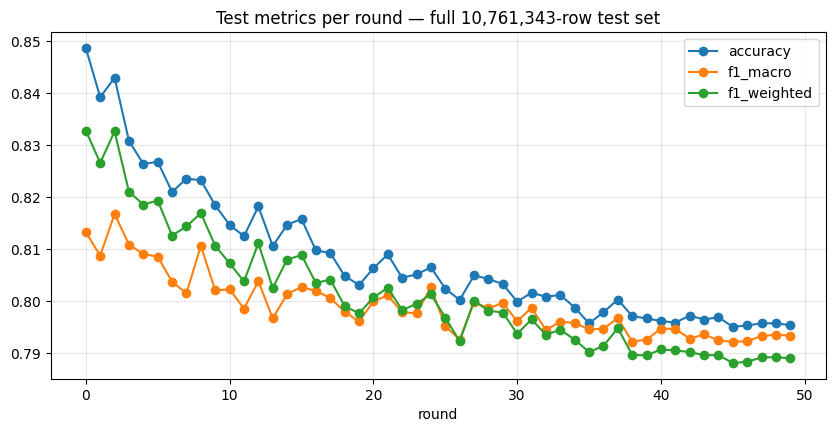

In [13]:
# ── Cell 20 · results ────────────────────────────────────────────────────────
import pandas as pd
from proj.metrics import METRIC_KEYS

hist = (pd.read_csv(RUN_DIR / "metrics" / "history.csv")
          .drop_duplicates(subset="round", keep="last")   # a re-run round appends a 2nd row
          .sort_values("round").reset_index(drop=True))
print(f"{len(hist)} / {CFG.rounds} rounds completed")
display(hist[["round", *METRIC_KEYS]].round(5))

ax = hist.plot(x="round", y=["accuracy", "f1_macro", "f1_weighted"],
               marker="o", figsize=(10, 4.5))
ax.set_title("Test metrics per round — full 10,761,343-row test set")
ax.set_xlabel("round"); ax.grid(alpha=.3)

best = hist.loc[hist["f1_macro"].idxmax()]
final = hist.iloc[-1]
print(f"\nbest round : {int(best['round'])}  f1_macro {best['f1_macro']:.5f}")
print(f"final round: {int(final['round'])}  f1_macro {final['f1_macro']:.5f}")
print(f"\nwall time  : {hist['seconds'].sum()/3600:.2f} h over {len(hist)} rounds "
      f"({hist['seconds'].mean()/60:.1f} min/round, {hist['samples_per_sec'].mean():,.0f} samples/s)")

print(f"\n{'='*72}\nFINAL 10 METRICS (round {int(final['round'])})\n{'='*72}")
for k in METRIC_KEYS:
    print(f"  {k:<22} {final[k]:.6f}")
print("\nNote: precision_micro = recall_micro = f1_micro = recall_weighted = accuracy.")
print("This identity holds for any single-label multi-class problem — it is not a bug.")

print(f"\n{'='*72}\nPER-CLASS REPORT (round {int(final['round'])})\n{'='*72}")
print(open(RUN_DIR / "reports" / f"round_{int(final['round']):03d}.txt").read())

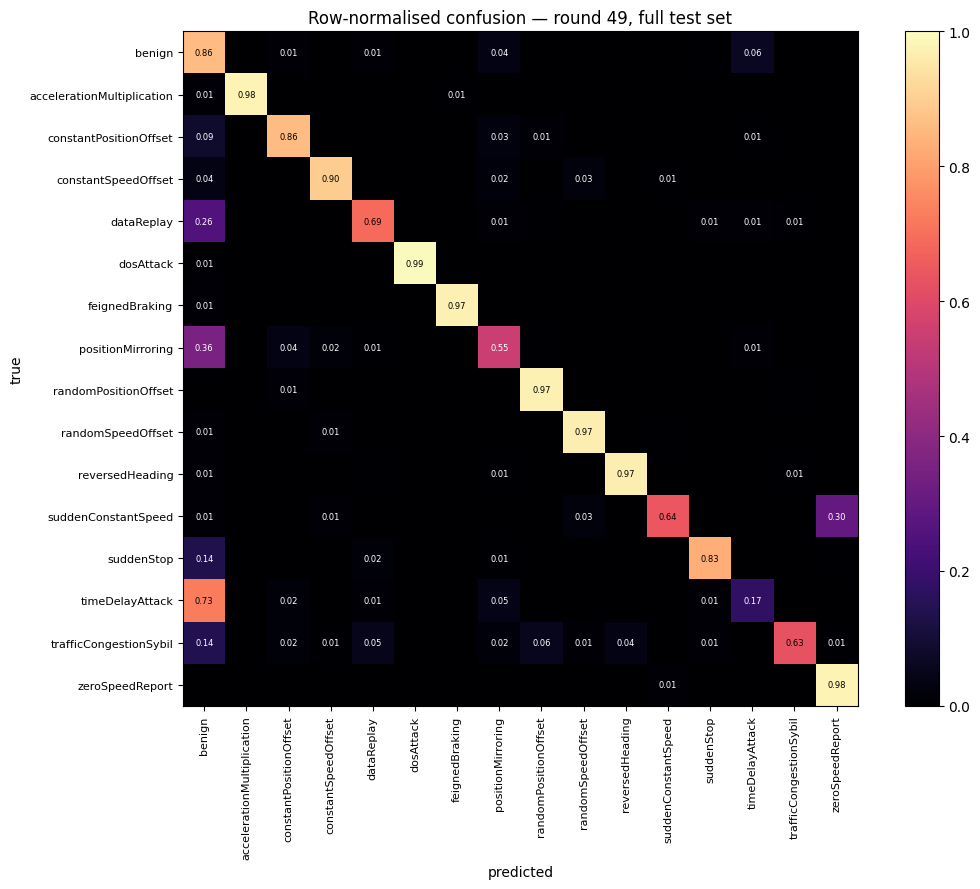

trafficCongestionSybil     precision 0.9856  recall 0.6313  f1 0.7696
timeDelayAttack            precision 0.3265  recall 0.1741  f1 0.2271


In [14]:
# ── Cell 21 · confusion matrix ───────────────────────────────────────────────
import matplotlib.pyplot as plt

cm = np.load(RUN_DIR / "confusion" / f"round_{int(final['round']):03d}.npy")
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cmn, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Row-normalised confusion — round {int(final['round'])}, full test set")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cmn[i, j] > 0.005:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if cmn[i, j] < 0.6 else "black")
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

# the two classes the dataset card singles out
for name in ("trafficCongestionSybil", "timeDelayAttack"):
    if name in CLASS_NAMES:
        i = CLASS_NAMES.index(name)
        rec = cm[i, i] / max(cm[i].sum(), 1)
        prec = cm[i, i] / max(cm[:, i].sum(), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        print(f"{name:<26} precision {prec:.4f}  recall {rec:.4f}  f1 {f1:.4f}")

## How to read these numbers

The ten metrics above are **16-class** on a **time-split** V2X dataset. The paper's
headline figures — Table 3 accuracy 0.99125, F-measure 0.98455; Table 4 accuracy 0.991 on
CIC-IDS 2017 — are **binary** normal/anomaly classification on different data under a
different metric convention (specificity, NPV, MCC, FPR, FNR, all of which need a TN that
16 classes do not define without an averaging choice). They are not comparable, and are
deliberately not tabulated side by side. What carries over from the paper is the *method*,
not the number.

State all of the following with any figure quoted from this notebook:

1. The split is by **simulation time**, not by vehicle — 64 cut points, one per
   (class × scenario).
2. Benign comes from an **attack-free stream**, which makes the `rate` feature group
   unusually strong.
3. **3,338,358 ambiguous rows** (manipulated but unflagged upstream) were dropped from the
   source before this dataset existed.
4. **⚠ Sybil.** 100.00% of `trafficCongestionSybil` rows sit in a flow where every row is a
   first-in-session row, so the 16 `session` features are very nearly a label for that
   class. **No ablation was run in this build**, so a high Sybil F1 above is substantially
   attributable to the `session` group rather than to DAGSNet, and this run cannot separate
   the two. The measurement that would is a second 50-round run with the `session` group
   zeroed.
5. `timeDelayAttack` is the hardest class.
6. Class imbalance is **41:1** — which is why `f1_macro` is the number that matters and
   `accuracy` is close to uninformative.
7. **88% of test flows are one message long**, almost all Sybil. They are kept: DAGSNet is
   a per-row classifier that never assembles a flow, so nothing was filtered. Filtering
   short flows here would delete most of a class.
8. CMSO was fitted on a **train-only** subsample with a train-only holdout. The test set
   was never used for selection, tuning, or early stopping.

Raw `y_pred` is saved for every round and `y_prob` for the best and final rounds, so any
further metric — the paper's binary-style set included — is recomputable from
`runs/<run_name>/preds/` without retraining.